In [1]:
import pandas as pd

df = pd.read_csv("data/lending_club_preprocessed.csv", parse_dates=['issue_d', 'earliest_cr_line'])


C:\Users\user\AppData\Local\Temp\ipykernel_2412\1692897667.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("data/lending_club_preprocessed.csv", parse_dates=['issue_d', 'earliest_cr_line'])


# 희상님 코드기반

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------
# 1) Mann-Whitney U + 효과크기(rbc)
# -----------------------------
def rank_biserial_from_u(u_stat, n0, n1):
    return 1 - (2 * u_stat) / (n0 * n1)

def effect_label_rbc(abs_rbc):
    if abs_rbc < 0.1:
        return "negligible"
    elif abs_rbc < 0.3:
        return "small"
    elif abs_rbc < 0.5:
        return "medium"
    return "large"

def mannwhitney_table(df, target_col, num_cols):
    rows = []
    for col in num_cols:
        g0 = df.loc[df[target_col] == 0, col].dropna()
        g1 = df.loc[df[target_col] == 1, col].dropna()

        if len(g0) < 3 or len(g1) < 3:
            rows.append({
                "feature": col, "test": "Mann-Whitney U", "u_stat": np.nan, "p_value": np.nan,
                "significant_0.05": np.nan, "effect_size_rbc": np.nan, "effect_magnitude": "insufficient_n",
                "median_y0": g0.median() if len(g0) else np.nan,
                "median_y1": g1.median() if len(g1) else np.nan
            })
            continue

        u_stat, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
        rbc = rank_biserial_from_u(u_stat, len(g0), len(g1))

        rows.append({
            "feature": col, "test": "Mann-Whitney U", "u_stat": u_stat, "p_value": p,
            "significant_0.05": p < 0.05, "effect_size_rbc": rbc,
            "effect_magnitude": effect_label_rbc(abs(rbc)),
            "median_y0": g0.median(), "median_y1": g1.median()
        })

    # 빈 결과여도 컬럼 유지 (KeyError 방지)
    cols = ["feature", "test", "u_stat", "p_value", "significant_0.05",
            "effect_size_rbc", "effect_magnitude", "median_y0", "median_y1"]
    return pd.DataFrame(rows, columns=cols).sort_values("p_value", na_position="last").reset_index(drop=True)


# -----------------------------
# 2) 카이제곱 + Cramer's V
# -----------------------------
def chi2_cramers_v(df, feature_col, target_col):
    temp = df[[feature_col, target_col]].dropna()
    ct = pd.crosstab(temp[feature_col], temp[target_col])

    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return {"feature": feature_col, "chi2": np.nan, "dof": np.nan, "p_value": np.nan, "cramers_v": np.nan, "note": "insufficient_levels"}

    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.to_numpy().sum()
    r, c = ct.shape
    denom = n * min(r - 1, c - 1)
    v = np.sqrt(chi2 / denom) if denom > 0 else np.nan

    return {"feature": feature_col, "chi2": chi2, "dof": dof, "p_value": p, "cramers_v": v, "note": ""}

def chi2_table(df, target_col, cat_cols):
    rows = [chi2_cramers_v(df, col, target_col) for col in cat_cols]
    cols = ["feature", "chi2", "dof", "p_value", "cramers_v", "note"]  # 빈 결과여도 컬럼 유지
    return pd.DataFrame(rows, columns=cols).sort_values("p_value", na_position="last").reset_index(drop=True)


# -----------------------------
# 3) 히스토그램 + QQ plot (y=0, y=1)
# -----------------------------
def plot_hist_qq_by_target(df, target_col, feature_col, bins=30):
    g0 = df.loc[df[target_col] == 0, feature_col].dropna()
    g1 = df.loc[df[target_col] == 1, feature_col].dropna()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"{feature_col} | Histogram + QQ plot", fontsize=14)

    sns.histplot(g0, bins=bins, kde=True, ax=axes[0, 0], color="#4C72B0")
    axes[0, 0].set_title(f"Histogram (y=0), n={len(g0)}")

    stats.probplot(g0, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title("QQ plot (y=0)")

    sns.histplot(g1, bins=bins, kde=True, ax=axes[1, 0], color="#DD8452")
    axes[1, 0].set_title(f"Histogram (y=1), n={len(g1)}")

    stats.probplot(g1, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title("QQ plot (y=1)")

    plt.tight_layout()
    plt.show()


,feature,test,u_stat,p_value,significant_0.05,effect_size_rbc,effect_magnitude,median_y0,median_y1
0,num_actv_rev_tl,Mann-Whitney U,118712124578.00,0.000e+00,True,0.0983,negligible,5.000,5.000
1,mths_since_recent_inq,Mann-Whitney U,118895369608.00,0.000e+00,True,-0.0858,negligible,5.000,4.000


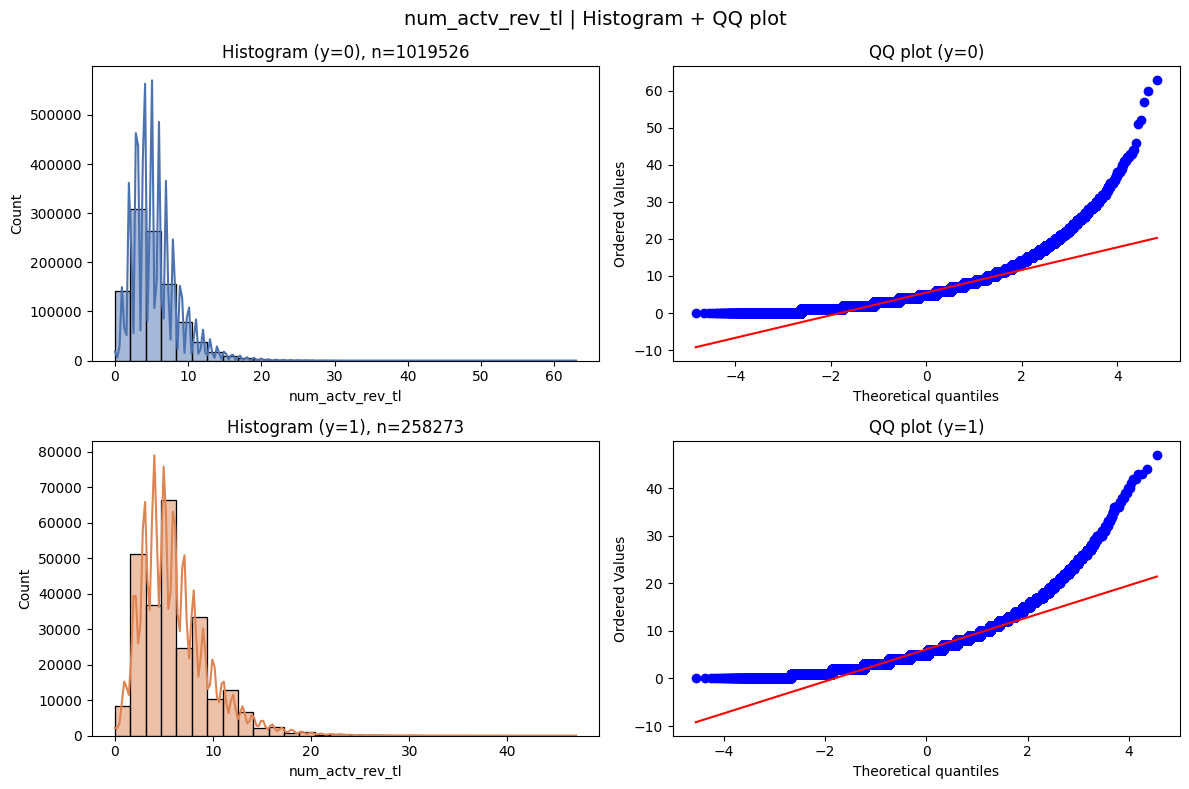

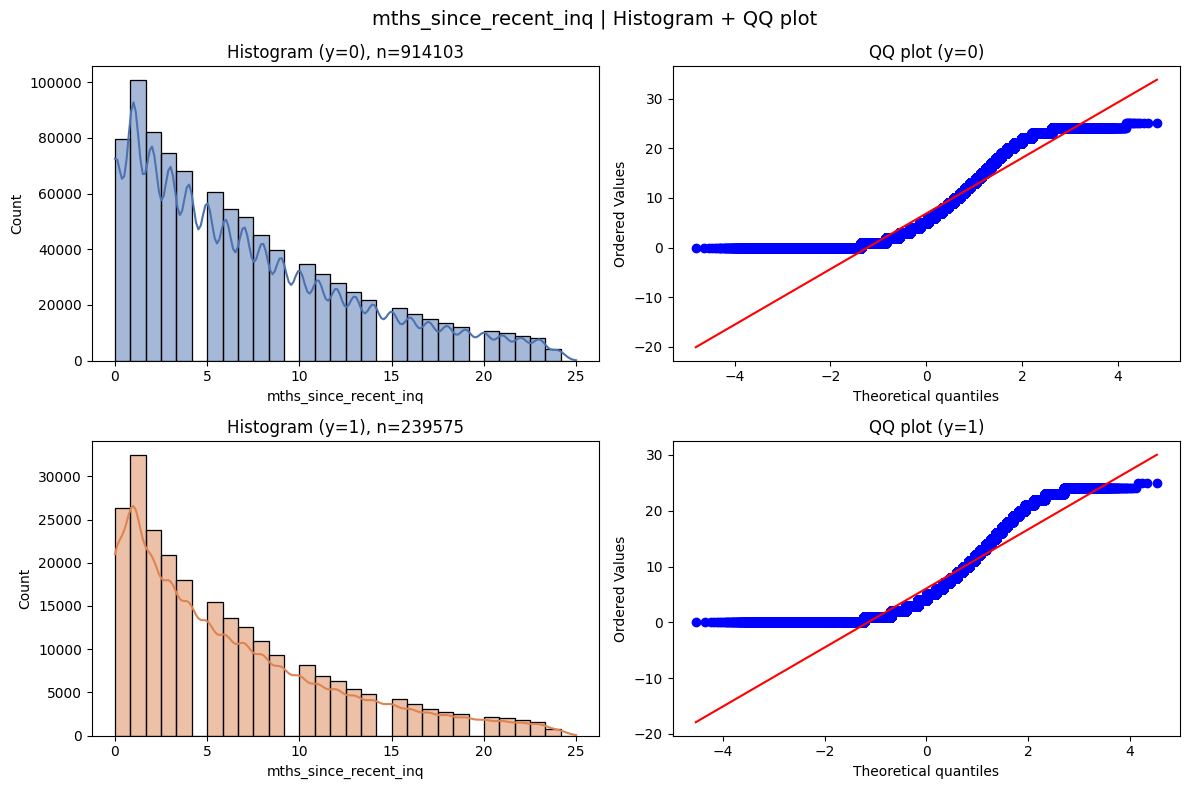

In [12]:
# -----------------------------
# 4) 실행 예시
# -----------------------------
target_col = "target"

target_col = "target"
selected_features = ["num_actv_rev_tl", "mths_since_recent_inq"]

# 1) Mann-Whitney 결과도 두 변수만
mw_res = mannwhitney_table(df, target_col, selected_features)
display(mw_res.style.format({
    "u_stat": "{:.2f}",
    "p_value": "{:.3e}",
    "effect_size_rbc": "{:.4f}",
    "median_y0": "{:.3f}",
    "median_y1": "{:.3f}"
}))

# 2) QQ plot + 히스토그램도 두 변수만
for col in selected_features:
    plot_hist_qq_by_target(df, target_col, col, bins=30)
